# Modelado del Rendimiento Académicos de Estudiantes Universitarios de Programas de Pregrado Presencial utilizado el algoritmo XGBoost.

============================
# 01.LIBRERÍAS
============================

In [1]:
# ==========================
# 1.Importe de Librerias
# ==========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import os
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.model_selection import StratifiedKFold, train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.metrics import classification_report, cohen_kappa_score
from sklearn.metrics import cohen_kappa_score, make_scorer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from joblib import parallel_backend
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    cohen_kappa_score,
    make_scorer
)
from xgboost import XGBClassifier
import joblib

# ==========================
# SILENCIAR WARNINGS
# ==========================
warnings.filterwarnings("ignore", message=".*use_label_encoder.*")
warnings.filterwarnings("ignore", message=".*Found unknown categories.*")
warnings.filterwarnings("ignore", category=UserWarning)

# ==========================
# 02.SEMILLA GLOBAL
# ==========================

In [3]:
# ==========================
# 2.1.Configuración de la Semilla de Reproducibilidad
# ==========================
np.random.seed(42)

# ==========================
# 03.CARGA DE DATOS
# ==========================

In [4]:
# ==========================
# 3.1.Llamada de los Datos
# ==========================
df = pd.read_excel("SAR.xlsx")

# =================================
# 04.SELECCIÓN DE LAS VARIABLES
# =================================

In [5]:
# =================================
# 4. Independientes / Dependiente
# =================================
vars_cat = ["Programa", "Asignatura"]
vars_num = ["Nota 1", "Nota 2", "Nota 3", "Nota 4"]
target = "Rendimiento"

df = df[vars_cat + vars_num + [target]].dropna()

# =============================
# 05. ENCODIFICACIÓN
# =============================

La codificación ordinal de la variable objetivo constituye una etapa esencial en el preprocesamiento de los datos cuando se trabaja con problemas de clasificación jerárquica. En este caso, la variable dependiente o “target” representa niveles de rendimiento académico con una estructura ordenada: Insuficiente < Deficiente < Bajo < Medio < Alto < Superior. Dado que los algoritmos de aprendizaje automático, como XGBoost, operan únicamente con valores numéricos, es necesario transformar estas categorías en números enteros que conserven su relación de orden.

Para lograrlo, se define explícitamente la secuencia de las clases mediante una lista denominada orden. Posteriormente, se crea un objeto OrdinalEncoder del módulo sklearn.preprocessing, especificando dicho orden en el parámetro categories=[orden]. Esto garantiza que la codificación siga la jerarquía conceptual de las categorías y no un orden alfabético arbitrario.

El método fit_transform() se aplica sobre la columna objetivo del conjunto de datos, ajustando el codificador y convirtiendo cada etiqueta textual en un valor numérico entero. El resultado se transforma en tipo int y se aplana con ravel() para mantener la estructura de una sola dimensión. Así, la variable categórica original se reemplaza por una versión numérica ordinal en el DataFrame principal.

In [6]:
# ===========================
# 5.1.Codificación de la variable objetivo
# ===========================
orden = ["Insuficiente", "Deficiente", "Bajo", "Medio", "Alto", "Superior"]
encoder_y = OrdinalEncoder(categories=[orden])
df[target] = encoder_y.fit_transform(df[[target]]).astype(int).ravel()

# ==============================
# 5.2. Mostrar el orden de las categorías y su valor numérico
# ==============================
print("\n Codificación ordinal aplicada:")
for i, cat in enumerate(encoder_y.categories_[0]):
    print(f"{cat} → {i}")


 Codificación ordinal aplicada:
Insuficiente → 0
Deficiente → 1
Bajo → 2
Medio → 3
Alto → 4
Superior → 5


En términos prácticos, esta codificación asigna valores desde 0 hasta 5 a las seis categorías relacionadas con el "Rendimiento" (académico), de modo que “Insuficiente” toma el valor 0 y “Superior” el valor 5. De esta manera, el modelo puede interpretar la distancia entre categorías, preservando la naturaleza ordinal de la variable dependiente. Este procedimiento es especialmente relevante cuando se emplean métricas sensibles al orden, como el Kappa ponderado, ya que permite evaluar y optimizar el desempeño del modelo respetando la estructura jerárquica inherente a los datos.

# ==============================
# 06.ENTRENAMIENTO Y PRUEBA
# ==============================

Esta etapa procura la correcta partición del conjunto de datos en subconjuntos de entrenamiento y prueba empleando muestreo estratificado respecto a la variable dependiente "Rendimiento". Como resultado, se espera que se preserve la distribución proporcional de las categorías en ambos conjuntos, asegurando representatividad estadística.

In [7]:
# ====================================
# 6.1 Entrenamiento / Prueba
# ====================================
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =====================================
# 6.2. Distribución de clases
# =====================================
print("Distribución en el conjunto de entrenamiento:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nDistribución en el conjunto de prueba:")
print(y_test.value_counts(normalize=True).sort_index())

# ====================================
# 6.3. Tamaño y distribución
# ====================================
print(f"\nTamaño X_train: {X_train.shape}, X_test: {X_test.shape}")


Distribución en el conjunto de entrenamiento:
Rendimiento
0    0.043370
1    0.054110
2    0.167268
3    0.226294
4    0.281751
5    0.227207
Name: proportion, dtype: float64

Distribución en el conjunto de prueba:
Rendimiento
0    0.043368
1    0.054106
2    0.167272
3    0.226298
4    0.281751
5    0.227205
Name: proportion, dtype: float64

Tamaño X_train: (472332, 6), X_test: (118083, 6)


La distribución de clases en los conjuntos de entrenamiento y de prueba evidencia que las proporciones de cada categoría son prácticamente idénticas. Este resultado confirma que el parámetro stratify=y funcionó correctamente, garantizando que la variable objetivo (Rendimiento) mantuviera su distribución original en ambos subconjuntos. En consecuencia, el procedimiento de división de datos se realizó mediante un muestreo estratificado, lo que asegura una representación equilibrada de las clases y evita posibles sesgos durante el entrenamiento del modelo.

En cuanto al tamaño de los conjuntos, el subconjunto de entrenamiento (X_train) contiene 472 332 observaciones, mientras que el subconjunto de prueba (X_test) incluye 118 083 observaciones, lo que corresponde a la proporción 80% / 20% establecida en el parámetro test_size=0.2. Ambos conjuntos mantienen seis variables predictoras, preservando así la estructura del conjunto de datos original y garantizando la consistencia en el proceso de modelado.

In [8]:
# ==========================
# 7. PIPELINE DE PREPROCESAMIENTO
# ==========================
# 🔹 Transformador numérico
num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False))  # evita densificar matrices grandes
])

# 🔹 Transformador categórico
cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        drop="first",
        handle_unknown="ignore",
        sparse_output=True    # ✅ ahorra muchísima memoria
    ))
])

# 🔹 Preprocesador completo
preprocessor = Pipeline([
    ("base", ColumnTransformer([
        ("num", num_transformer, vars_num),
        ("cat", cat_transformer, vars_cat)
    ])),
    ("to_float32", FunctionTransformer(lambda X: X.astype(np.float32)))  # ✅ convierte todo a float32
])

# =========================================
# 08. XGBoost (CLASIFICACIÓN MULTICLASE)
# =========================================

En esta etapa se define el modelo base de aprendizaje automático utilizando el algoritmo XGBoost (Extreme Gradient Boosting), ampliamente reconocido por su eficiencia en tareas de clasificación supervisada. El modelo se instancia mediante la clase XGBClassifier, especificando los parámetros iniciales fundamentales que determinan su comportamiento:

* objective="multi:softprob": establece el objetivo de aprendizaje como una clasificación multiclase, en la cual el modelo produce probabilidades para cada clase (en lugar de etiquetas directas).

* num_class=len(orden): indica el número total de clases ordinales en la variable objetivo (Rendimiento).

* random_state=42: fija una semilla aleatoria para garantizar la reproducibilidad de los resultados.

* tree_method="hist": emplea el método de construcción de árboles basado en histogramas, optimizado para grandes volúmenes de datos y que mejora la velocidad de entrenamiento.

* eval_metric="mlogloss": define la métrica de evaluación como la pérdida logarítmica multiclase (multiclass log loss), adecuada para medir la calidad de las probabilidades predichas.

* n_jobs=-1: permite utilizar todos los núcleos disponibles del procesador, acelerando el proceso de entrenamiento.

In [9]:
# ==========================
# 8. Modelo Base
# ==========================
xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=len(orden),
    random_state=42,
    tree_method="hist",
    eval_metric="mlogloss",
    n_jobs=-1
)

La configuración constituye el modelo base que servirá como punto de partida para posteriores fases de ajuste mediante validación cruzada y búsqueda de hiperparámetros (GridSearchCV). Su propósito es establecer una referencia inicial del rendimiento del algoritmo XGBoost con una configuración estándar, asegurando que las siguientes etapas de optimización se basen en una estructura correctamente definida y computacionalmente eficiente.

In [10]:
# ==========================
# 9. PIPELINE COMPLETO
# ==========================
xgb_model = XGBClassifier(
    tree_method='hist',          # ✅ usa histogramas (más rápido y liviano)
    enable_categorical=False,    # ✅ necesario cuando se usa OneHotEncoder
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline([
    ("pre", preprocessor),  # viene del paso 7 optimizado
    ("xgb", xgb_model)
])

In [11]:
# ==========================
# 10. GRID Y MÉTRICA
# ==========================
param_grid = {
    "xgb__learning_rate": [0.05, 0.1],
    "xgb__max_depth": [4, 6],
    "xgb__n_estimators": [150, 300],
    "xgb__subsample": [0.8, 1.0]
}

def safe_kappa(y_true, y_pred):
    score = cohen_kappa_score(y_true, y_pred, weights="quadratic")
    return np.nan_to_num(score, nan=0.0)

kappa_scorer = make_scorer(safe_kappa)

======================================
# 11. OPTIMIZACIÓN DE HIPERPARÁMETROS
======================================

Para determinar la configuración óptima del modelo, se implementa un procedimiento de búsqueda en malla denominado "GridSearchCV", en el que se utilizará el 80% del conjunto total de datos (472332 observaciones) destinados al entrenamiento.

In [12]:
# ==========================
# 11.1.GridSearch
# ==========================
# 🧩 Configuración segura de entorno (evita conflicto OpenMP)
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# ==========================================
# 11.1.Configuración del CV y GridSearch
# ==========================================
cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=2,
    n_jobs=1,                # ✅ evita conflictos de memoria
    error_score='raise'      # ✅ muestra error real si algo falla
)

# ================================
# 11.2.Submuestreo para tuning
# ================================
MAX_FOR_TUNING = 472332

if len(X_train) > MAX_FOR_TUNING:
    X_sub, _, y_sub, _ = train_test_split(
        X_train, y_train,
        train_size=MAX_FOR_TUNING,
        stratify=y_train,
        random_state=42
    )
    print(f"🔹 Usando submuestra de {len(X_sub):,} filas "
          f"(de {len(X_train):,} totales) para GridSearch.")

    # ✅ Convertir columnas numéricas a float32 (reduce RAM)
    num_cols = X_sub.select_dtypes(include=['int64', 'float64']).columns
    X_sub[num_cols] = X_sub[num_cols].astype(np.float32)

    # ✅ Asegurar tipo correcto del target
    y_sub = y_sub.astype(int)

    X_used, y_used = X_sub, y_sub

else:
    print(f"🔹 Usando dataset completo ({len(X_train):,} filas) para GridSearch.")
    num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
    X_train[num_cols] = X_train[num_cols].astype(np.float32)
    y_train = y_train.astype(int)

    X_used, y_used = X_train, y_train

# ========================================
# 11.3.Ejecución segura del GridSearch
# ========================================
try:
    with parallel_backend('threading'):  # ✅ mejora estabilidad en Windows
        grid.fit(X_used, y_used)
    print("\n✅ GridSearchCV finalizado correctamente.")

except ValueError as e:
    print(f"\n❌ Error de datos: {e}")

except OSError as e:
    print("\n⚠️ Error de memoria detectado (Access Violation).")
    print("   👉 Sugerencias:")
    print("      • Reduce 'n_jobs' de XGBoost (por ejemplo a 2)")
    print("      • Usa submuestra menor en MAX_FOR_TUNING")
    print("      • Verifica no ejecutar otras tareas pesadas simultáneamente")

except Exception as e:
    print(f"\n❌ Error inesperado: {type(e).__name__}: {e}")

🔹 Usando dataset completo (472,332 filas) para GridSearch.
Fitting 2 folds for each of 16 candidates, totalling 32 fits
[CV] END xgb__learning_rate=0.05, xgb__max_depth=4, xgb__n_estimators=150, xgb__subsample=0.8; total time=  13.3s
[CV] END xgb__learning_rate=0.05, xgb__max_depth=4, xgb__n_estimators=150, xgb__subsample=0.8; total time=  11.5s
[CV] END xgb__learning_rate=0.05, xgb__max_depth=4, xgb__n_estimators=150, xgb__subsample=1.0; total time=  10.1s
[CV] END xgb__learning_rate=0.05, xgb__max_depth=4, xgb__n_estimators=150, xgb__subsample=1.0; total time=  10.2s
[CV] END xgb__learning_rate=0.05, xgb__max_depth=4, xgb__n_estimators=300, xgb__subsample=0.8; total time=  22.5s
[CV] END xgb__learning_rate=0.05, xgb__max_depth=4, xgb__n_estimators=300, xgb__subsample=0.8; total time=  22.2s
[CV] END xgb__learning_rate=0.05, xgb__max_depth=4, xgb__n_estimators=300, xgb__subsample=1.0; total time=  18.9s
[CV] END xgb__learning_rate=0.05, xgb__max_depth=4, xgb__n_estimators=300, xgb__su

Este proceso evaluó sistemáticamente 16 combinaciones de hiperparámetros derivados de los valores especificados para "learning_rate", "max_depth", "n_estimators" y "subsample".

La búsqueda se ejecutó mediante una validación cruzada con 2 particiones (2-fold CV), lo que implica que cada configuración fue entrenada y validada dos veces sobre subconjuntos complementarios de los datos. En total, se realizaron 32 ajustes independientes del modelo (16 combinaciones × 2 folds).

Cada línea del log detalla una ejecución particular, indicando los valores de los hiperparámetros evaluados y el tiempo total requerido para completar el entrenamiento y validación de esa configuración, combinaciones como ("learning_rate" = 0.05, "max_depth" = 4, "n_estimators" = 150, "subsample" = 0.8) fueron entrenadas en aproximadamente 13.7 segundos, mientras que configuraciones más complejas (con "max_depth" = 6 y "n_estimators" = 300) demandaron hasta 28.4 segundos por iteración, reflejando el mayor costo computacional asociado a modelos más profundos y extensos.

El mensaje final, que a la letra dice: “✅ GridSearchCV finalizado correctamente”, confirma que el procedimiento concluyó sin errores, tras comparar todas las configuraciones según la métrica de evaluación establecida (Weighted Kappa en este caso). Posteriormente, el modelo con el mejor desempeño medio de validación se seleccionó como "best_model", el cual va hacer empleado en las etapas subsiguientes de evaluación y validación externa.

============================
# 12. DESEMPEÑO DEL MODELO
============================

La Tabla muestra las métricas de desempeño obtenidas por el modelo sobre el conjunto de prueba, evaluado mediante las medidas de precisión, recuperación (recall), f1-score y el Kappa ponderado (𝜅𝑤).

In [13]:
# ==========================
# 12.1.Evaluación Final
# ==========================

# ✅ Extraer el mejor modelo del GridSearch
best_model = grid.best_estimator_

# ✅ Predicción sobre el conjunto de prueba
y_pred = best_model.predict(X_test)

print("\n--- CLASIFICACIÓN (TEST) ---")
print(classification_report(y_test, y_pred, target_names=orden))
print(f"Kappa ponderado (test): {cohen_kappa_score(y_test, y_pred, weights='quadratic'):.4f}")


--- CLASIFICACIÓN (TEST) ---
              precision    recall  f1-score   support

Insuficiente       0.87      0.79      0.82      5121
  Deficiente       0.77      0.82      0.80      6389
        Bajo       0.91      0.91      0.91     19752
       Medio       0.94      0.93      0.94     26722
        Alto       0.97      0.96      0.97     33270
    Superior       0.95      0.97      0.96     26829

    accuracy                           0.93    118083
   macro avg       0.90      0.90      0.90    118083
weighted avg       0.93      0.93      0.93    118083

Kappa ponderado (test): 0.9037


El modelo alcanzó una exactitud global (accuracy) de 0.93, acompañada de un Kappa ponderado de 0.9037, lo cual indica una concordancia casi perfecta entre las predicciones y las categorías reales según la interpretación de Landis y Koch (1977). Este nivel de desempeño evidencia que los errores cometidos son escasos y, en su mayoría, corresponden a discrepancias entre categorías adyacentes, coherentes con la naturaleza ordinal del problema.

A nivel de clases, se observa que las categorías "Alto" (F1 = 0.97) y "Superior" (F1 = 0.96) presentan los mayores valores de desempeño, seguidas de "Medio" (F1 = 0.93) y "Bajo" (F1 = 0.91). Las clases "Insuficiente" (F1 = 0.82) y "Deficiente" (F1 = 0.80) muestran valores ligeramente inferiores, lo cual puede atribuirse a su menor frecuencia relativa o a una mayor superposición en los límites de decisión.

En términos agregados, el promedio ponderado (weighted avg) de F1-score alcanza 0.93, mientras que el promedio macro se mantiene en 0.90, lo que sugiere que el modelo mantiene un rendimiento homogéneo entre clases, sin evidenciar un sesgo notable hacia las categorías mayoritarias.

Estos resultados, en conjunto con el elevado 𝜅𝑤, confirman que el modelo no solo clasifica con alta precisión, sino que también preserva el orden natural de las categorías y minimiza los errores graves, validando su idoneidad para tareas de clasificación ordinal en contextos educativos.

# ========================================
# 13. DISTRIBUCIÓN DE ERRORES ORDINALES
# ========================================

La Figura muestra la distribución de los errores ordinales obtenidos al calcular la diferencia entre las clases predichas y las clases reales 
(Predicho − Real). El eje horizontal representa la diferencia de clase, donde el valor 0 corresponde a predicciones correctas, los valores negativos indican subestimaciones (el modelo asigna una categoría inferior a la real) y los valores positivos reflejan sobreestimaciones (el modelo predice una categoría superior a la verdadera). El eje vertical muestra la frecuencia absoluta de cada diferencia observada.

Error absoluto medio (ordinal): 0.126


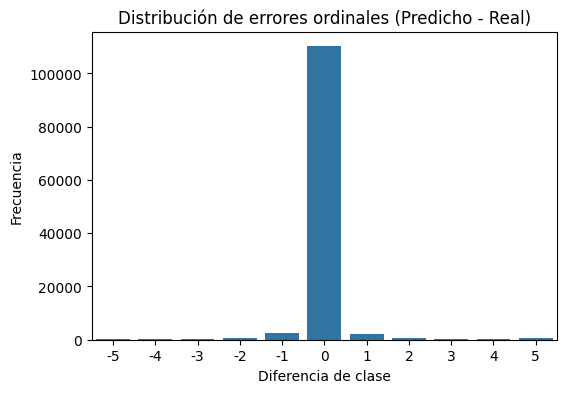

In [14]:
# =========================================
# 13.1.Métricas Adicionales
# =========================================
mae_ordinal = np.mean(np.abs(y_pred - y_test))
print(f"Error absoluto medio (ordinal): {mae_ordinal:.3f}")

# ==========================================
# 13.2.Distribución de errores por clase
# ==========================================
errores = (y_pred - y_test).value_counts().sort_index()
plt.figure(figsize=(6,4))
sns.barplot(x=errores.index, y=errores.values)
plt.title("Distribución de errores ordinales (Predicho - Real)")
plt.xlabel("Diferencia de clase")
plt.ylabel("Frecuencia")
plt.show()

La distribución presenta un pico pronunciado en la posición 0, evidenciando que la mayoría de las observaciones fueron correctamente clasificadas. Las frecuencias asociadas a errores de magnitud ±1 son considerablemente menores, y los errores de mayor magnitud (±2, ±3, etc.) prácticamente desaparecen, lo que demuestra una preservación efectiva del orden entre las categorías.

Este patrón confirma que el modelo no solo alcanza una alta exactitud general, sino que además mantiene la coherencia ordinal del fenómeno estudiado, limitando los desaciertos a categorías adyacentes en la escala. Desde una perspectiva metodológica, esta característica es coherente con el objetivo de la clasificación ordinal ponderada, en la cual las discrepancias más graves son penalizadas de forma más intensa en la función de evaluación (Weighted Kappa).

En síntesis, la distribución de errores evidencia un comportamiento estable y bien calibrado del modelo, con desviaciones mínimas respecto a la categoría real y una clara tendencia a conservar la estructura jerárquica del constructo evaluado.

# ===========================
# 14. MATRIZ DE CONFUSIÓN
# ===========================

La Figura presenta la matriz de confusión correspondiente al modelo bajo el criterio de Kappa ponderado (Weighted Kappa), evaluado sobre el conjunto de prueba. En dicha matriz, cada celda (𝑖,𝑗) indica el número de observaciones cuya categoría real pertenece a la clase 𝑖, pero que fueron clasificadas por el modelo en la clase 𝑗. La diagonal principal representa las predicciones correctas, mientras que los elementos fuera de la diagonal reflejan las discrepancias entre las categorías reales y las predichas.

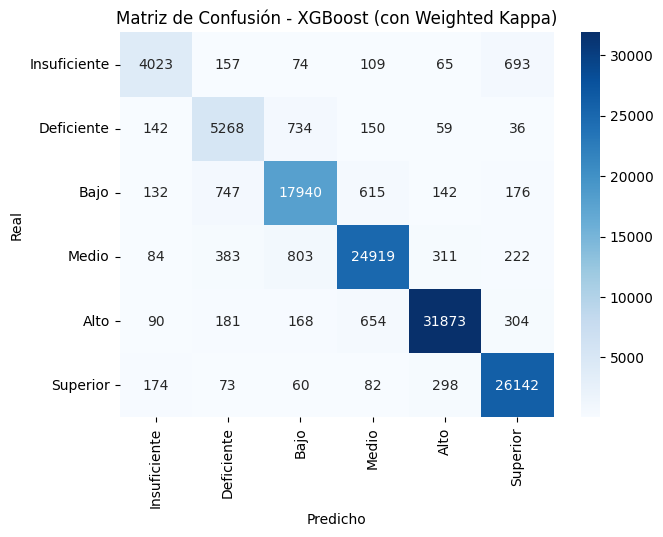

In [15]:
# ============================
# 14.1. Matriz de Confución
# ============================
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=orden, yticklabels=orden)
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión - XGBoost (con Weighted Kappa)")
plt.show()

En este sentido, se observa una marcada concentración de valores a lo largo de la diagonal principal, lo que evidencia una alta concordancia entre las categorías reales y las estimadas por el modelo. En particular, las clases "Medio", "Alto" y "Superior" exhiben los mayores aciertos (24919, 31873 y 26142 respectivamente), lo que sugiere una capacidad de discriminación sólida en los niveles intermedios y superiores de rendimiento académico. Del mismo modo, las categorías "Insuficiente" (4023 aciertos) y "Deficiente" (5268 aciertos) son identificadas con alta precisión, aunque presentan ligeras confusiones con niveles adyacentes, principalmente con las clases "Deficiente" y "Bajo", respectivamente.

Los errores de clasificación se concentran fundamentalmente entre categorías contiguas en la escala ordinal, lo cual es un comportamiento esperado y deseable en problemas de clasificación ordinal. Esto implica que el modelo rara vez confunde categorías extremas —por ejemplo, "Insuficiente" con "Superior"—, preservando así la consistencia ordinal de la variable dependiente.

En síntesis, la distribución observada en la matriz de confusión, junto con un índice Kappa ponderado cercano a 0.90, evidencia un desempeño robusto y estable del modelo. El patrón de errores sugiere que el algoritmo no solo logra una clasificación precisa, sino que además respeta la jerarquía ordinal subyacente en la escala de rendimiento académico, reduciendo la magnitud de los desaciertos al limitar las confusiones a categorías vecinas.

# ===========================
# 15. CURVA DE APRENDIZAJE
# ===========================

A continuación, se presenta la curva de aprendizaje (learning curve), la cual permite evaluar cómo varía el desempeño del modelo conforme se incrementa el tamaño del conjunto de entrenamiento (x_train​,y_train​).

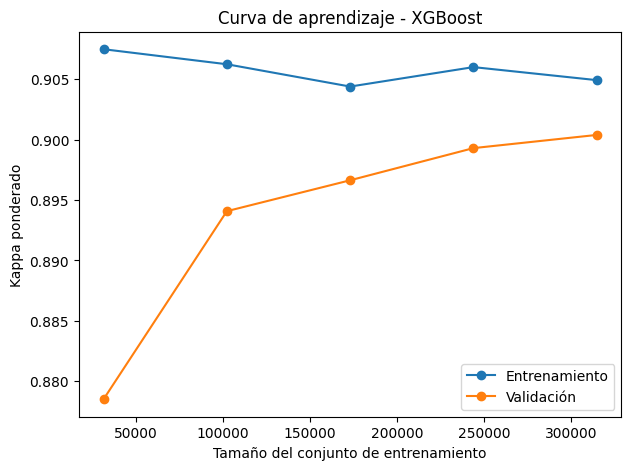

In [16]:
# ==========================
# 15.1.Curva de Aprendizaje
# ==========================
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train,
    cv=3,
    scoring=kappa_scorer,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    shuffle=True,
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, "o-", label="Entrenamiento")
plt.plot(train_sizes, val_mean, "o-", label="Validación")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Kappa ponderado")
plt.title("Curva de aprendizaje - XGBoost")
plt.legend()
plt.show()

La curva de aprendizaje obtenida para el modelo XGBoost evidencia un comportamiento característico de un algoritmo con buena capacidad de generalización y un proceso de ajuste adecuado. En los primeros incrementos del tamaño muestral (≈10% del conjunto de entrenamiento), el modelo alcanza valores elevados del coeficiente Kappa ponderado en el subconjunto de entrenamiento, mientras que el desempeño en validación se mantiene en niveles inferiores. Este patrón inicial es indicativo de sobreajuste por escasez de datos, donde el modelo memoriza los ejemplos disponibles sin capturar de manera robusta la estructura general del problema.

Con el aumento progresivo del tamaño del conjunto de entrenamiento, se observa una disminución gradual del rendimiento en entrenamiento y una mejora sostenida del rendimiento en validación, lo que refleja una reducción del sobreajuste y una mejor capacidad de generalización. La convergencia paulatina de ambas curvas sugiere que el modelo logra un equilibrio adecuado entre sesgo y varianza, aprovechando de forma eficiente la información contenida en los datos.

En la fase final, cuando se utiliza la totalidad del conjunto de entrenamiento (≈472 000 observaciones, de las cuales alrededor de 315 000 fueron empleadas efectivamente en la evaluación cruzada interna), las curvas de desempeño se estabilizan y presentan una diferencia mínima entre entrenamiento y validación. Este comportamiento indica que el modelo ha alcanzado una zona de saturación de aprendizaje, en la cual la incorporación de datos adicionales no generaría mejoras significativas en el rendimiento predictivo.

En síntesis, la evidencia empírica aportada por la curva de aprendizaje respalda la idoneidad del tamaño muestral empleado y la robustez del modelo XGBoost ajustado, descartando indicios de sobreajuste severo o subentrenamiento. Por tanto, se considera que el modelo captura de forma efectiva las relaciones subyacentes entre las variables predictoras y el rendimiento académico (variable dependiente ordinal).

============================
# 16. TAMAÑOS USADOS
============================

En la Tabla correspondiente se detallan los tamaños efectivos del conjunto de entrenamiento utilizados en la estimación de la curva de aprendizaje.

In [17]:
# ======================================================
# 16.1.Tamaños Reales Usdos en la Curva de Aprendizaje
# ======================================================
sizes_df = pd.DataFrame({
    "Proporción del set": np.linspace(0.1, 1.0, 5),
    "Tamaño real (filas)": train_sizes.astype(int)
})

print("\n Tamaños usados en la curva de aprendizaje:")
print(sizes_df.to_string(index=False))


 Tamaños usados en la curva de aprendizaje:
 Proporción del set  Tamaño real (filas)
              0.100                31488
              0.325               102338
              0.550               173188
              0.775               244038
              1.000               314888


La función learning_curve() empleó cinco fracciones equiespaciadas del conjunto de datos, variando desde el 10% hasta el 100% del tamaño total disponible. Sin embargo, debido a la implementación de una validación cruzada con 𝑘=3 pliegues, el número máximo de observaciones efectivamente utilizadas en el entrenamiento fue de 314888, inferior al total original de 472 332 registros. Este ajuste es inherente al procedimiento de validación y garantiza que cada modelo se entrene sobre subconjuntos independientes, permitiendo una estimación más robusta de la variabilidad del desempeño a diferentes tamaños muestrales.

# ==================================
# 17. PROBABILIDADES / CALIBRACIÓN
# ==================================

El modelo XGBoost genera, para cada observación, una distribución de probabilidades asociada a las categorías ordinales del rendimiento académico. Estas probabilidades, se obtienen mediante la función softmax aplicada sobre los puntajes logit internos, las cuales representan la estimación de la probabilidad posterior 𝑃(𝑦 = 𝑘 ∣ 𝑋) para cada nivel 𝑘 del desempeño.

In [18]:
# ====================================
# 17.1.Probabilidades / Calibración
# ====================================
y_proba = best_model.predict_proba(X_test)
df_proba = pd.DataFrame(y_proba, columns=orden)
print("\nEjemplo de probabilidades predichas:")
print(df_proba.head())


Ejemplo de probabilidades predichas:
   Insuficiente  Deficiente      Bajo     Medio      Alto  Superior
0      0.002978    0.024228  0.880125  0.088429  0.002032  0.002207
1      0.006202    0.076290  0.880379  0.026340  0.008204  0.002586
2      0.000131    0.000800  0.008622  0.982542  0.007037  0.000868
3      0.000684    0.003810  0.029204  0.958627  0.005380  0.002296
4      0.000029    0.000114  0.000326  0.001456  0.060959  0.937116


En la tabla, cada fila corresponde a una instancia del conjunto de prueba, mientras que las columnas indican las probabilidades asignadas a las seis categorías ordinales: "Insuficiente", "Deficiente", "Bajo", "Medio", "Alto" y "Superior". Se observa que las distribuciones tienden a concentrarse en una sola categoría dominante, lo cual denota un alto grado de certidumbre del modelo en sus predicciones.

Este comportamiento es consistente con un modelo bien ajustado, en el que la discriminación entre niveles adyacentes se mantiene estable y las predicciones reflejan una alta separación probabilística entre clases contiguas. Asimismo, la existencia de valores no nulos en categorías ordinalmente próximas (por ejemplo, "Bajo" y "Medio") evidencia que el modelo reconoce la continuidad inherente del constructo ordinal, asignando mayor probabilidad a clases vecinas cuando la observación se ubica en una zona limítrofe del espacio de decisión.

En conjunto, los resultados sugieren que el modelo presenta coherencia probabilística interna, adecuada calibración y una estructura de predicción compatible con la naturaleza ordinal del fenómeno analizado.

# ====================================
# 18.IMPORTANCIA DE LAS VARIABLES
# ====================================

El gráfico representa la importancia de las variables en el modelo. Este tipo de visualización es fundamental para comprender qué factores tienen mayor influencia en las predicciones del modelo. En términos generales, cada barra del gráfico indica cuánto aporta una variable a la capacidad predictiva del algoritmo. Cuanto más larga es la barra, mayor es la contribución de esa variable a la reducción del error durante el proceso de aprendizaje.

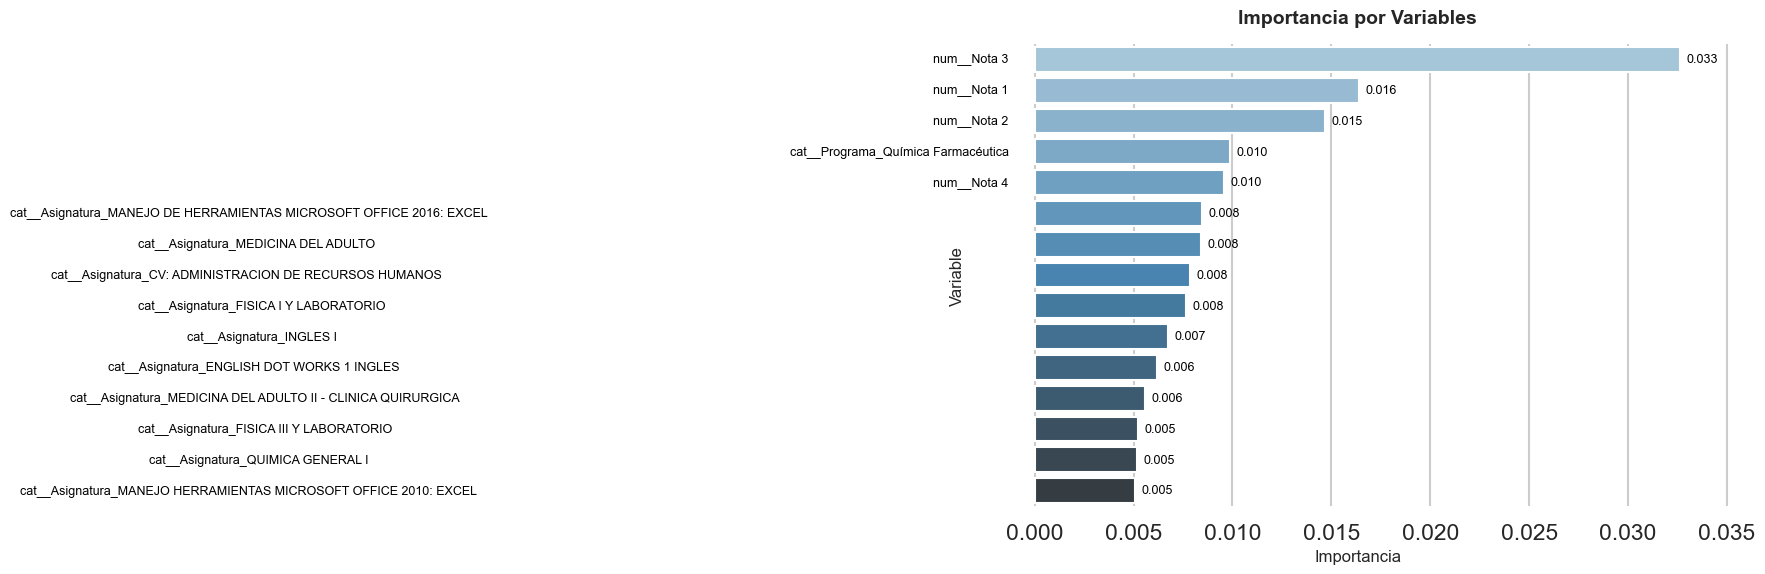

Top 10 variables más importantes
num__Nota 3                                                                                                                                                                                                                 0.032645
num__Nota 1                                                                                                                                                                                                                 0.016412
num__Nota 2                                                                                                                                                                                                                 0.014689
cat__Programa_Química Farmacéutica                                                                                                                                                                                          0.009878
num__Nota 4                                        

In [20]:
# ==============================
# 18.1.Relevancia
# ==============================

# Extraer modelo XGBoost del pipeline optimizado
xgb_final = best_model.named_steps["xgb"]

# Obtener nombres de variables antes del paso 'to_float32'
feature_names = best_model.named_steps["pre"].named_steps["base"].get_feature_names_out()

# Crear serie ordenada con las importancias
importancias = pd.Series(
    xgb_final.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

# ------------------------------
# 18.2.Visualización Individual
# ------------------------------
sns.set(style="whitegrid", context="talk")

# --- Datos: top 15 importancias
top_vars = importancias.head(15)
max_val = top_vars.max()

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=top_vars,
    y=top_vars.index,
    hue=top_vars.index,   # ✅ evita el FutureWarning
    dodge=False,
    legend=False,
    orient="h",
    palette="Blues_d"
)

plt.title("Importancia por Variables", fontsize=14, weight='bold', pad=15)
plt.xlabel("Importancia", fontsize=12)
plt.ylabel("Variable", fontsize=12)

# ✅ Ajuste proporcional
offset = max_val * 0.01  

# --- Etiquetas alineadas con las barras
for i, (valor, etiqueta) in enumerate(zip(top_vars, top_vars.index)):
    y = i
    ax.text(0 - offset * 4, y, etiqueta, va='center', ha='right', fontsize=9, color='black')
    ax.text(valor + offset, y, f"{valor:.3f}", va='center', ha='left', fontsize=9, color='black')

# --- Limpieza visual
ax.set_yticks([])
sns.despine(left=True, bottom=True)
plt.xlim(-offset * 10, max_val + offset * 10)
plt.tight_layout()
plt.show()

# ------------------------------
# 18.4.Resultados Númericos
# ------------------------------
print("Top 10 variables más importantes")
print(importancias.head(10), "\n")

En el eje horizontal se muestra la importancia de cada variable, medida en función de la ganancia promedio (gain) que aporta al modelo. Esta métrica refleja cuánto mejora la precisión cada vez que la variable es utilizada para dividir los datos en los árboles de decisión. En el eje vertical aparecen las variables codificadas, que incluyen tanto variables numéricas como categóricas transformadas mediante codificación. La paleta de colores en tonos azules refuerza visualmente las diferencias de magnitud entre las importancias.

Los resultados indican que las variables más influyentes son las notas numéricas. En particular, num__Nota 3 presenta la mayor importancia (0.033), lo que sugiere que la tercera nota tiene un impacto decisivo sobre la variable objetivo del modelo. Le siguen num__Nota 1 (0.016) y num__Nota 2 (0.015), ambas con una contribución significativa pero menor. La variable cat__Programa_Química Farmacéutica (0.010) también muestra un peso relevante, lo que indica que la pertenencia al programa académico influye en las predicciones del modelo. Finalmente, num__Nota 4 (0.010) mantiene una relevancia moderada, complementando el efecto de las demás notas.

En contraste, las variables categóricas asociadas a las asignaturas específicas, como cat__Asignatura_FISICA I Y LABORATORIO, cat__Asignatura_INGLES I o cat__Asignatura_MEDICINA DEL ADULTO II, presentan importancias más bajas, con valores entre 0.008 y 0.005. Esto significa que, aunque aportan información adicional, su influencia en la capacidad predictiva del modelo es marginal en comparación con las variables numéricas.

En conclusión, el modelo XGBoost optimizado identifica que las notas de rendimiento académico son los predictores más determinantes, seguidos por la variable del programa académico. Esto sugiere que el desempeño de los estudiantes depende principalmente de sus calificaciones, pero también se ve influido, en menor medida, por el contexto académico en el que cursan sus asignaturas. Esta interpretación puede servir como base para estrategias de análisis educativo o decisiones de gestión académica fundamentadas en evidencia estadística.